In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# 1. 数据生成配置
def generate_synthetic_data(n_samples=2000, seed=42):
    np.random.seed(seed)
    # 生成 5 个特征，但只有前 4 个有用 (x5 是噪音)
    X = np.random.normal(0, 1, (n_samples, 5))
    
    # 真实函数: y = x0 + x1 + x2 * x3 (注意索引从0开始)
    # y = x[0] + x[1] + x[2]*x[3]
    # x[4] 是纯噪音
    y = X[:, 0] + X[:, 1] + X[:, 2] * X[:, 3] + np.random.normal(0, 0.1, n_samples)
    
    return X, y

# 2. 计算 Ground Truth Shapley Values
def get_ground_truth_shapley(X):
    # 依据公式: phi_i = value_added_by_i
    # 对于加性项 x0, x1 -> phi = x
    # 对于交互项 x2*x3 -> phi = (x2*x3)/2 (在均值为0且独立时成立)
    
    shap_gt = np.zeros_like(X)
    shap_gt[:, 0] = X[:, 0]
    shap_gt[:, 1] = X[:, 1]
    shap_gt[:, 2] = (X[:, 2] * X[:, 3]) / 2
    shap_gt[:, 3] = (X[:, 2] * X[:, 3]) / 2
    shap_gt[:, 4] = 0 # 噪音特征贡献为0
    
    return shap_gt

X, y = generate_synthetic_data()
shap_gt = get_ground_truth_shapley(X)

# 转换为 Tensor
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).unsqueeze(1)
shap_gt_tensor = torch.FloatTensor(shap_gt)

# 划分数据
train_dataset = TensorDataset(X_tensor[:1600], y_tensor[:1600])
test_dataset = TensorDataset(X_tensor[1600:], y_tensor[1600:], shap_gt_tensor[1600:])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [2]:
import torch.nn as nn
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from src.instashap import InstaSHAP, ShapleySampler

# 手动构造交互列表和变换矩阵
# interactions[0] 是空的或占位符，后续从索引 1 开始
# 我们希望模型学习: f1(x0), f2(x1), f3(x2, x3), f4(x4)
known_interactions = [[], [0], [1], [2, 3], [4]] 
num_features = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 构造 Transform Matrix (映射特征到交互组)
# 形状: (num_features, num_interaction_groups)
# 组索引从 0 开始对应 known_interactions[1:]
transform_matrix = torch.zeros((num_features, len(known_interactions)-1))

for group_idx, features in enumerate(known_interactions[1:]): # group_idx 0 -> [0]
    for feat_idx in features:
        transform_matrix[feat_idx, group_idx] = 1.0

print("Transform Matrix:\n", transform_matrix)

# 初始化模型
model = InstaSHAP(
    interactions=known_interactions,
    transform_matrix=transform_matrix,
    device=device
)

Transform Matrix:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


/opt/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch.optim as optim
from tqdm import tqdm

optimizer = optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()
sampler = ShapleySampler(num_features=num_features)

model.train()
print("Starting Simulation Training...")

for epoch in range(30): # 简单跑30轮
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # 1. 采样 Shapley 掩码 S
        S = sampler.sample(batch_x.shape[0], paired_sampling=True).to(device)
        
        # 2. 前向传播 (InstaSHAP 预测 masked output)
        optimizer.zero_grad()
        # 注意: InstaSHAP 的 forward 需要 (x, S)
        preds = model(batch_x, S)
        
        # 3. 计算损失 (目标是拟合 y)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Starting Simulation Training...
Epoch 5, Loss: 1.8672
Epoch 10, Loss: 1.8031
Epoch 15, Loss: 1.7631
Epoch 20, Loss: 1.7018
Epoch 25, Loss: 1.7721
Epoch 30, Loss: 1.7978



Simulation Result - Shapley MSE: 0.008255


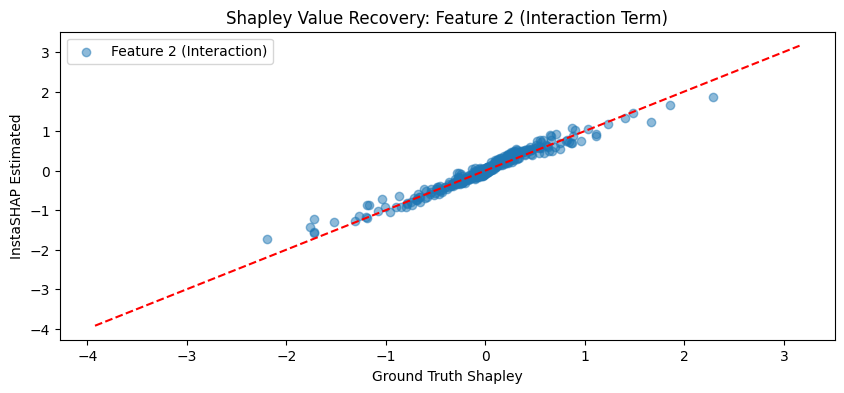

In [4]:
model.eval()
with torch.no_grad():
    X_test, _, gt_shaps = test_dataset[:]
    X_test = X_test.to(device)
    
    # 获取 InstaSHAP 估算的 Shapley Values
    # 注意: get_shapley_values 返回的是每个 interaction group 的值
    # 形状: (N, num_groups) -> 这里是 (N, 4) 对应 [0], [1], [2,3], [4]
    estimated_groups = model.get_shapley_values(X_test).cpu()
    
    #我们需要把 Group Shapley 映射回 Feature Shapley
    # 对于单特征组 [0], [1], [4]，值直接对应
    # 对于交互组 [2, 3]，值通常需要平分给特征 (在 Shapley 定义下)
    
    estimated_features = torch.zeros_like(gt_shaps)
    
    # Group 0 -> Feature 0
    estimated_features[:, 0] = estimated_groups[:, 0]
    # Group 1 -> Feature 1
    estimated_features[:, 1] = estimated_groups[:, 1]
    # Group 2 -> Feature 2 & 3 (交互项平分)
    estimated_features[:, 2] = estimated_groups[:, 2] / 2
    estimated_features[:, 3] = estimated_groups[:, 2] / 2
    # Group 3 -> Feature 4
    estimated_features[:, 4] = estimated_groups[:, 3]

    # 计算 MSE
    shap_mse = torch.mean((estimated_features - gt_shaps)**2)
    print(f"\nSimulation Result - Shapley MSE: {shap_mse.item():.6f}")

    # 可视化对比 (Feature 2: Interaction Term)
    plt.figure(figsize=(10, 4))
    plt.scatter(gt_shaps[:, 2], estimated_features[:, 2], alpha=0.5, label='Feature 2 (Interaction)')
    plt.plot([gt_shaps.min(), gt_shaps.max()], [gt_shaps.min(), gt_shaps.max()], 'r--')
    plt.xlabel("Ground Truth Shapley")
    plt.ylabel("InstaSHAP Estimated")
    plt.title("Shapley Value Recovery: Feature 2 (Interaction Term)")
    plt.legend()
    plt.show()

Training InstaSHAP on Synthetic Data...

      MULTI-PERSPECTIVE EVALUATION      
1. Explanation MSE (Lower is better):  0.087583
2. Feature Rank Correlation (Spearman): 0.9150
3. Active Feature Avg Importance:       1.4273
4. Noise Feature Avg Importance:        0.0974 (Should be ~0)
   -> Noise/Signal Ratio:               0.0683


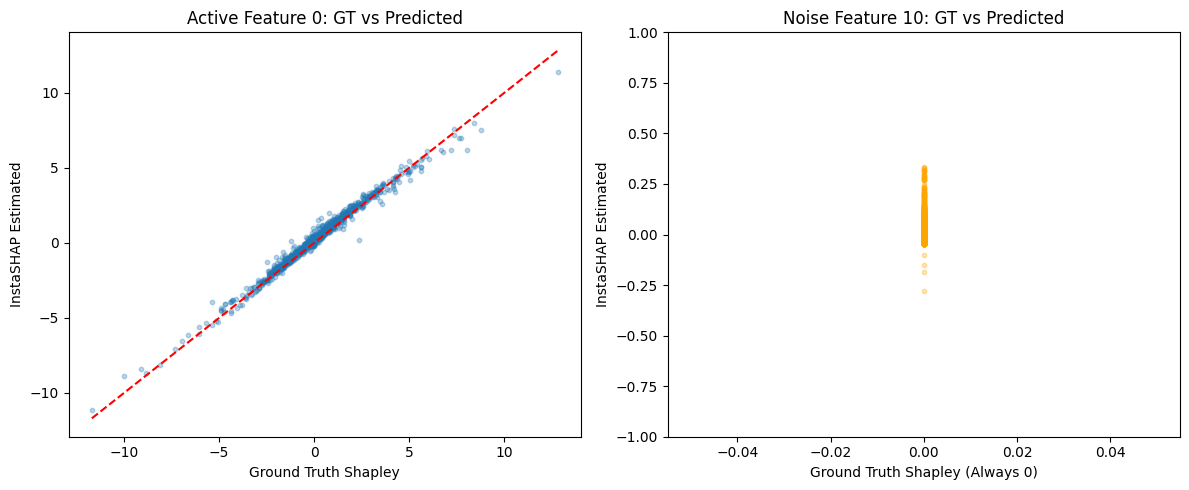

In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from torch.utils.data import TensorDataset, DataLoader
from src.instashap import InstaSHAP, ShapleySampler # 假设你已经有这些类

# ==========================================
# 1. 复杂合成数据生成 (10 Feats + 10 Interactions)
# ==========================================
class ComplexSyntheticGen:
    def __init__(self, n_samples=5000, seed=42):
        self.n_samples = n_samples
        self.rng = np.random.default_rng(seed)
        
        # 设定: 10个有效特征 (0-9), 10个噪音特征 (10-19)
        self.n_features = 20 
        self.active_features = list(range(10))
        
        # 定义 10 个交互对 (Indices)
        # 例如: (0,1), (1,2), ..., (9,0) 形成一个环
        self.interactions = [(i, (i + 1) % 10) for i in range(10)]
        
        # 随机生成系数以增加难度
        self.main_coeffs = self.rng.uniform(0.5, 2.0, 10)
        self.inter_coeffs = self.rng.uniform(1.0, 3.0, 10)  # 交互项权重通常大一些以便观察

    def generate(self):
        # 生成 X (均值为0，独立)
        X = self.rng.normal(0, 1, (self.n_samples, self.n_features))
        
        # 计算 y 和 Ground Truth Shapley
        # y = sum(alpha * x) + sum(beta * xi * xj)
        y = np.zeros(self.n_samples)
        shap_gt = np.zeros_like(X)
        
        # 1. Main Effects
        for i in self.active_features:
            effect = self.main_coeffs[i] * X[:, i]
            y += effect
            shap_gt[:, i] += effect # 主效应完全归因于 i
            
        # 2. Interaction Effects
        for idx, (u, v) in enumerate(self.interactions):
            # Interaction term: beta * x_u * x_v
            effect = self.inter_coeffs[idx] * X[:, u] * X[:, v]
            y += effect
            
            # Shapley Axiom: 对于 x_u * x_v，贡献平分
            shap_gt[:, u] += effect / 2
            shap_gt[:, v] += effect / 2
            
        # 添加一点观测噪音
        y += self.rng.normal(0, 0.1, self.n_samples)
        
        return X, y, shap_gt, self.interactions

# ==========================================
# 2. 仿真执行函数
# ==========================================
def run_simulation():
    # A. 准备数据
    gen = ComplexSyntheticGen(n_samples=5000)
    X, y, shap_gt, interactions_list = gen.generate()
    
    # 转换为 Tensor
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tensor = torch.FloatTensor(X).to(device)
    y_tensor = torch.FloatTensor(y).unsqueeze(1).to(device)
    
    # 划分 Train/Test
    n_train = 4000
    train_data = TensorDataset(X_tensor[:n_train], y_tensor[:n_train])
    test_X = X_tensor[n_train:]
    test_shap_gt = shap_gt[n_train:]
    
    train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
    
    # B. 配置 InstaSHAP 模型结构
    # 我们需要构建 interactions 列表传给 InstaSHAP
    # 结构: [[], [0], [1]... [19], [0,1], [1,2]...]
    # 包含: 空集(0), 单特征(1-20), 交互对(21-30)
    
    model_interactions = [[]] 
    # 添加所有单特征 (包括噪音，看模型能否学会忽略)
    for i in range(20):
        model_interactions.append([i])
    # 添加真实交互项
    for u, v in interactions_list:
        model_interactions.append([u, v])
        
    # 构造 Transform Matrix (Num_Features x Num_Groups)
    num_groups = len(model_interactions) - 1 # 去掉空集
    transform_matrix = torch.zeros((20, num_groups))
    
    for g_idx, feats in enumerate(model_interactions[1:]):
        for f_idx in feats:
            transform_matrix[f_idx, g_idx] = 1.0
            
    # 初始化模型
    model = InstaSHAP(
        interactions=model_interactions,
        transform_matrix=transform_matrix,
        device=device,
    ).to(device)
    
    # C. 训练 (Distillation / Fitting)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    sampler = ShapleySampler(num_features=20)
    
    print("Training InstaSHAP on Synthetic Data...")
    model.train()
    for epoch in range(1000): # 训练 50 轮
        for bx, by in train_loader:
            S = sampler.sample(bx.shape[0], paired_sampling=True).to(device)
            optimizer.zero_grad()
            preds = model(bx, S)
            loss = criterion(preds, by)
            loss.backward()
            optimizer.step()
            
    # ==========================================
    # 3. 多维度评估 (Evaluation)
    # ==========================================
    model.eval()
    with torch.no_grad():
        # 获取预测的 Group Shapley Values
        # shape: (N_test, Num_Groups)
        group_shaps = model.get_shapley_values(test_X).cpu().numpy()
        
    # 将 Group Shapley 分配回 Feature Shapley
    pred_shap_features = np.zeros_like(test_shap_gt)
    
    # 映射逻辑:
    # Group 0-19 是 Main Effects (单特征) -> 直接加给对应特征
    # Group 20-29 是 Interactions (双特征) -> 平分给两个特征
    
    # 1. Main Effects (Groups 0 to 19)
    for i in range(20):
        pred_shap_features[:, i] += group_shaps[:, i]
        
    # 2. Interactions (Groups 20 to 29)
    for idx, (u, v) in enumerate(interactions_list):
        group_idx = 20 + idx
        pred_shap_features[:, u] += group_shaps[:, group_idx] / 2
        pred_shap_features[:, v] += group_shaps[:, group_idx] / 2

    # --- Metrics Calculation ---
    
    # 1. Explanation Fidelity (MSE)
    mse_shap = np.mean((pred_shap_features - test_shap_gt)**2)
    
    # 2. Rank Correlation (Global Importance)
    # Global Importance = mean(|phi_i|)
    gt_importance = np.mean(np.abs(test_shap_gt), axis=0)
    pred_importance = np.mean(np.abs(pred_shap_features), axis=0)
    rank_corr, _ = spearmanr(gt_importance, pred_importance)
    
    # 3. Noise Sparsity check
    # 计算噪音特征 (indices 10-19) 的平均归因值，理应接近 0
    noise_attribution = np.mean(np.abs(pred_shap_features[:, 10:]))
    active_attribution = np.mean(np.abs(pred_shap_features[:, :10]))
    
    print("\n" + "="*40)
    print("      MULTI-PERSPECTIVE EVALUATION      ")
    print("="*40)
    print(f"1. Explanation MSE (Lower is better):  {mse_shap:.6f}")
    print(f"2. Feature Rank Correlation (Spearman): {rank_corr:.4f}")
    print(f"3. Active Feature Avg Importance:       {active_attribution:.4f}")
    print(f"4. Noise Feature Avg Importance:        {noise_attribution:.4f} (Should be ~0)")
    print(f"   -> Noise/Signal Ratio:               {noise_attribution/active_attribution:.4f}")
    
    # 4. 可视化对比 (Feature 1 vs Feature 10 [Noise])
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(test_shap_gt[:, 0], pred_shap_features[:, 0], alpha=0.3, s=10)
    plt.plot([test_shap_gt[:,0].min(), test_shap_gt[:,0].max()], 
             [test_shap_gt[:,0].min(), test_shap_gt[:,0].max()], 'r--')
    plt.title("Active Feature 0: GT vs Predicted")
    plt.xlabel("Ground Truth Shapley")
    plt.ylabel("InstaSHAP Estimated")
    
    plt.subplot(1, 2, 2)
    plt.scatter(test_shap_gt[:, 10], pred_shap_features[:, 10], alpha=0.3, s=10, c='orange')
    plt.ylim(-1, 1) # 噪音应该集中在 0 附近
    plt.title("Noise Feature 10: GT vs Predicted")
    plt.xlabel("Ground Truth Shapley (Always 0)")
    plt.ylabel("InstaSHAP Estimated")
    
    plt.tight_layout()
    plt.show()

# 运行
run_simulation()

